In [31]:
import numpy as np
import matplotlib.pyplot as plt

spectral density $S_y(f) \propto f^\alpha$  => $Y(f) = \sqrt{S_y(f)} \propto f^{\alpha/2}$
- types
  - $\alpha=2$ - White PM (W PM) 
  - $\alpha=1$ - Flicker PM (F PM)
  - $\alpha=0$ - White FM (W FM)
  - $\alpha=-1$ - Flicker FM (F FM)
  - $\alpha=-2$ - Random Walk FM (RW FM)
  - $\alpha=-3$ - Flicker Walk FM (FW FM)
  - $\alpha=-4$ - Random Run FM (RR FM) 

In [32]:
def oscilator_generator(N, alpha, dt):
    # Generation of white noise oscillator 
    y = np.random.normal(0, 1, N)   # amplitudes in time domain   ("y" axis)

    # normalization to zero mean and unit std
    y = (y - np.mean(y)) / np.std(y)

    # amplitudes in frequency domain
    y_freq = np.fft.rfft(y)    # = amplitude * exp(i*phase)
    amplitudes = np.abs(y_freq)   # like  y = np.random.normal(0, 1, N) but in frequency domain   ("y" axis)
    phases = np.angle(y_freq)

    frequencies = np.fft.rfftfreq(N, dt)   # like time = np.arange(0, N*dt, dt) but for frequencies  ("x" axis)
    frequencies[0] = frequencies[1]   # to avoid division by zero

    # rescaled amplitudes in frequency domain
    amplitudes_rescaled = amplitudes * (frequencies ** (alpha / 2))

    # amplitudes rescaling according to power-law spectral density
    y_freq_rescaled =  amplitudes_rescaled * np.exp(1j * phases)

    # back to time domain
    y = np.fft.irfft(y_freq_rescaled)
    return y


def check_noise_type(y):
    # go to frequency domain
    y_freq = np.fft.rfft(y)
    amplitudes = np.abs(y_freq)

    # S \propto amplitudes^2
    S = amplitudes ** 2

    frequencies = np.fft.rfftfreq(len(y), dt)

    # get exponent alpha
    S_log = np.log(S[1:])   # avoid f = 0
    f_log = np.log(frequencies[1:])   # avoid f = 0
    alpha = np.polyfit(f_log, S_log, 1) [0]   

    # plot S(f) in log-log scale (expectation: straight line with slope = alpha)
    plt.loglog(frequencies[1:], S[1:])   # avoid f = 0
    plt.title(f'Power Spectral Density (alpha = {alpha:.2f})')
    plt.xlabel('Frequency')
    plt.ylabel('S(f)')
    plt.show()
    

In [33]:
N = 500
dt = 0.01 #s
time = np.arange(0, N*dt, dt)   # "x" axis

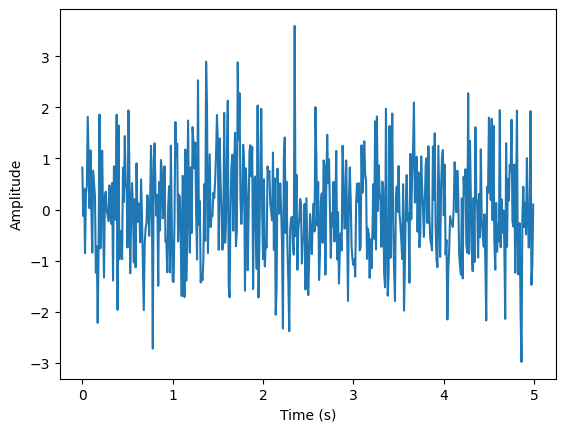

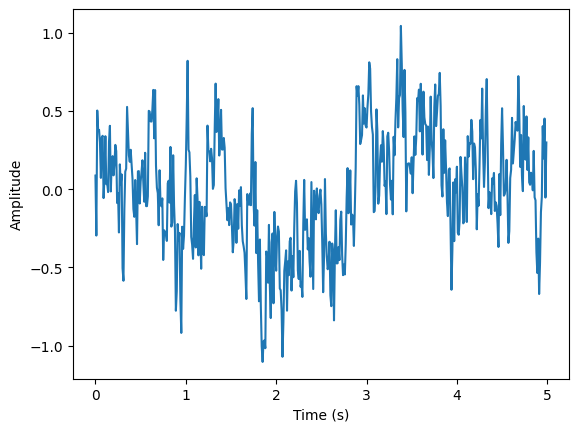

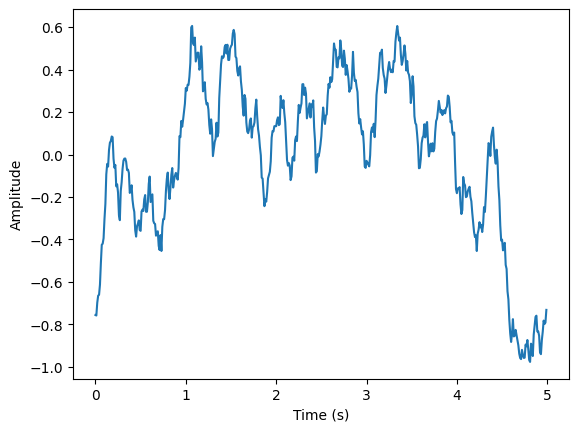

In [34]:
white_noise = oscilator_generator(N, 0, dt)
flicker_noise = oscilator_generator(N, -1, dt)
random_walk_noise = oscilator_generator(N, -2, dt)

plt.plot(time, white_noise)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

plt.plot(time, flicker_noise)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

plt.plot(time, random_walk_noise)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

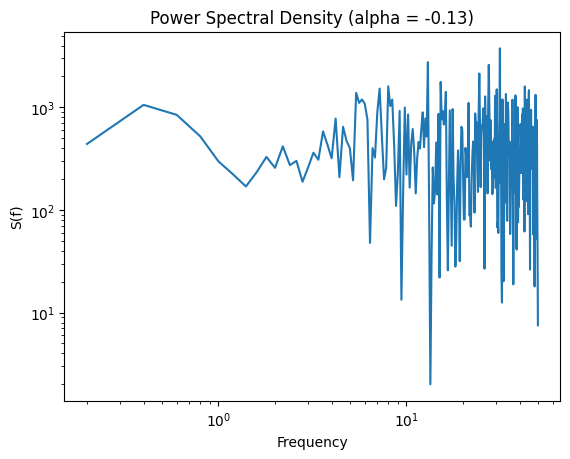

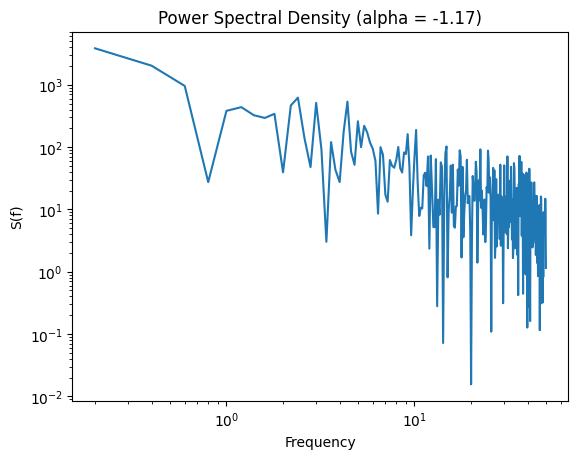

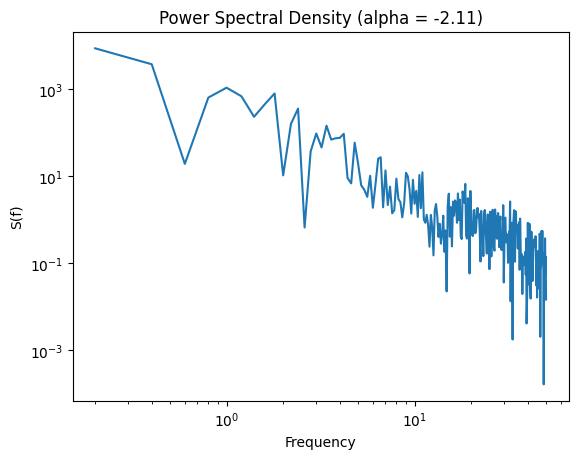

In [35]:
check_noise_type(white_noise)
check_noise_type(flicker_noise)
check_noise_type(random_walk_noise)